# 07a. Frequency-Domain Features & Correlation Analysis

## Objective

This notebook extracts frequency-domain wearable features from the preprocessed Parkinson's Disease Smartwatch Dataset (PADS) signals and identifies strongly correlated features.

Following the decision established in Notebook 04, each post-trim recording is first interpolated onto a **uniform 100 Hz grid** before FFT-based feature extraction. The interpolation preserves the established post-trim recording lengths of **976** and **2,000 samples**.

The notebook produces:

- a frequency-domain feature table;
- accelerometer and gyroscope frequency-feature groups;
- a Pearson correlation matrix;
- a summary of strongly correlated wearable features; and
- validation confirming that uniform resampling preserves the post-trim sample lengths.


## Frequency-Domain Features

For each accelerometer and gyroscope axis and magnitude signal, the following features are extracted:

- **Dominant frequency**
- **Spectral centroid**
- **Spectral entropy**
- **Spectral power**

The analysis includes accelerometer X, Y, Z, and magnitude, together with gyroscope X, Y, Z, and magnitude. This produces **32 frequency-domain features per recording**.


## Uniform 100 Hz Resampling

Notebook 04 found timestamp jitter in the raw smartwatch recordings and concluded that FFT-based features should be calculated only after interpolation onto a uniform 100 Hz grid.

The feature module therefore:

1. reads the post-trim preprocessed recordings;
2. replaces irregular timestamps with exact 0.01-second spacing;
3. linearly interpolates all accelerometer, gyroscope, and magnitude channels;
4. preserves the existing number of samples; and
5. performs the FFT using a fixed sampling frequency of 100 Hz.

The original timestamp-based sampling frequency is retained only as a quality-assurance field. It is not used for the FFT.


In [1]:
# Libraries and project paths
# =============================================================================

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

cwd = Path.cwd()

if (cwd / "data").exists() and (cwd / "src").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").exists() and (cwd.parent / "src").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root containing data/ and src/."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features.frequency_features import (
    TARGET_SAMPLING_FREQUENCY,
    build_correlation_summary,
    build_frequency_feature_table,
    compute_feature_correlations,
    get_accelerometer_feature_columns,
    get_frequency_feature_columns,
    get_gyroscope_feature_columns,
    summarize_strong_correlations,
)

NPZ_DIR = PROJECT_ROOT / "data" / "processed" / "preprocessed_signals"

FEATURE_OUTPUT = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "frequency_domain_features.csv"
)

CORRELATION_OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "correlation_analysis"
)

CORRELATION_MATRIX_OUTPUT = (
    CORRELATION_OUTPUT_DIR
    / "frequency_feature_correlation_matrix.csv"
)

STRONG_CORRELATIONS_OUTPUT = (
    CORRELATION_OUTPUT_DIR
    / "strongly_correlated_features.csv"
)

CORRELATION_SUMMARY_OUTPUT = (
    CORRELATION_OUTPUT_DIR
    / "correlation_analysis_summary.csv"
)

RESAMPLING_LENGTH_OUTPUT = (
    CORRELATION_OUTPUT_DIR
    / "post_resampling_length_summary.csv"
)

STRONG_CORRELATION_THRESHOLD = 0.80
EXPECTED_POST_TRIM_LENGTHS = {976, 2000}

print("Project root:", PROJECT_ROOT)
print("Processed signal directory:", NPZ_DIR)
print("Target sampling frequency:", TARGET_SAMPLING_FREQUENCY, "Hz")


Project root: c:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease
Processed signal directory: c:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\data\processed\preprocessed_signals
Target sampling frequency: 100.0 Hz


## 1. Confirm Input Availability

In [2]:
if not NPZ_DIR.exists():
    raise FileNotFoundError(
        f"Could not locate {NPZ_DIR}. "
        "Run or obtain the signal-preprocessing outputs first."
    )

npz_files = sorted(NPZ_DIR.glob("*_preprocessed.npz"))

if not npz_files:
    raise FileNotFoundError(
        f"No participant .npz files were found in {NPZ_DIR}."
    )

print("Participant NPZ files found:", len(npz_files))
print("First file:", npz_files[0].name)

assert len(npz_files) == 469, (
    f"Expected 469 participant files, found {len(npz_files)}."
)


Participant NPZ files found: 469
First file: 001_preprocessed.npz


## 2. Inspect the Preprocessed Signal Structure

In [3]:
with np.load(npz_files[0], allow_pickle=False) as sample:
    sample_columns = sample["__columns__"].astype(str).tolist()
    sample_recording_keys = (
        sample["__recording_keys__"].astype(str).tolist()
    )
    first_recording_key = sample_recording_keys[0]
    first_recording_shape = sample[first_recording_key].shape

print("Signal columns:", sample_columns)
print("Recordings in sample participant:", len(sample_recording_keys))
print("First recording key:", first_recording_key)
print("First recording shape:", first_recording_shape)

expected_columns = [
    "Time",
    "Accelerometer_X",
    "Accelerometer_Y",
    "Accelerometer_Z",
    "Gyroscope_X",
    "Gyroscope_Y",
    "Gyroscope_Z",
    "Acc_Magnitude",
    "Gyro_Magnitude",
]

missing_columns = [
    column
    for column in expected_columns
    if column not in sample_columns
]

assert not missing_columns
assert len(sample_recording_keys) == 22


Signal columns: ['Time', 'Accelerometer_X', 'Accelerometer_Y', 'Accelerometer_Z', 'Gyroscope_X', 'Gyroscope_Y', 'Gyroscope_Z', 'Acc_Magnitude', 'Gyro_Magnitude']
Recordings in sample participant: 22
First recording key: CrossArms__LeftWrist
First recording shape: (976, 9)


## 3. Extract Frequency-Domain Features After 100 Hz Resampling

In [4]:
frequency_features = build_frequency_feature_table(NPZ_DIR)

print("Frequency feature table shape:", frequency_features.shape)
print("Participants:", frequency_features["patient_id"].nunique())
print("Recordings:", len(frequency_features))
print("Tasks:", frequency_features["task"].nunique())
print("Wrists:", frequency_features["wrist"].nunique())

assert frequency_features["patient_id"].nunique() == 469
assert len(frequency_features) == 10_318

frequency_features.head()


Frequency feature table shape: (10318, 42)
Participants: 469
Recordings: 10318
Tasks: 11
Wrists: 2


,patient_id,recording_key,task,wrist,n_samples,original_sampling_frequency_hz,sampling_frequency_hz,resampled_n_samples,uniform_time_start_s,uniform_time_end_s,acc_x_dominant_frequency,acc_x_spectral_centroid,acc_x_spectral_entropy,acc_x_spectral_power,acc_y_dominant_frequency,acc_y_spectral_centroid,acc_y_spectral_entropy,acc_y_spectral_power,acc_z_dominant_frequency,acc_z_spectral_centroid,acc_z_spectral_entropy,acc_z_spectral_power,acc_magnitude_dominant_frequency,acc_magnitude_spectral_centroid,acc_magnitude_spectral_entropy,acc_magnitude_spectral_power,gyro_x_dominant_frequency,gyro_x_spectral_centroid,gyro_x_spectral_entropy,gyro_x_spectral_power,gyro_y_dominant_frequency,gyro_y_spectral_centroid,gyro_y_spectral_entropy,gyro_y_spectral_power,gyro_z_dominant_frequency,gyro_z_spectral_centroid,gyro_z_spectral_entropy,gyro_z_spectral_power,gyro_magnitude_dominant_frequency,gyro_magnitude_spectral_centroid,gyro_magnitude_spectral_entropy,gyro_magnitude_spectral_power
0,001,CrossArms__LeftWrist,CrossArms,LeftWrist,976,100.031100,100.0,976,0.0,9.75,0.819672,1.866823,0.526448,0.001782,1.229508,2.363701,0.557386,0.005342,0.922131,2.112073,0.540519,0.002527,0.102459,0.570117,0.234482,0.007209,0.204918,2.155251,0.597538,0.077220,0.307377,0.625410,0.400327,0.202952,0.409836,0.530284,0.372805,0.978077,0.102459,0.354928,0.292612,1.152311
1,001,CrossArms__RightWrist,CrossArms,RightWrist,976,99.344008,100.0,976,0.0,9.75,0.819672,1.663690,0.513621,0.001953,1.331967,2.608833,0.569853,0.004633,0.922131,2.334017,0.570797,0.002340,0.102459,0.719561,0.270446,0.006181,0.409836,0.997054,0.439185,0.240653,0.307377,0.528197,0.380307,0.271797,0.409836,0.538821,0.370770,0.829611,0.102459,0.365697,0.306318,1.201251
2,001,DrinkGlas__LeftWrist,DrinkGlas,LeftWrist,976,100.038257,100.0,976,0.0,9.75,0.614754,3.138822,0.640340,0.006228,7.889344,6.107938,0.759575,0.021786,0.922131,4.049227,0.680939,0.008750,0.204918,3.759089,0.683259,0.022893,0.307377,2.467019,0.619202,1.529727,0.204918,1.045782,0.457844,0.390406,0.102459,0.883988,0.442721,0.334447,0.102459,2.527846,0.629801,1.268809
3,001,DrinkGlas__RightWrist,DrinkGlas,RightWrist,976,99.353420,100.0,976,0.0,9.75,2.049180,3.303895,0.622688,0.017004,1.331967,5.656435,0.744571,0.014850,1.639344,3.113583,0.630309,0.018572,0.204918,2.382510,0.583509,0.025706,1.024590,2.503980,0.598465,1.204848,1.844262,2.019669,0.562906,1.187956,0.102459,1.570955,0.537322,0.564632,0.102459,1.353934,0.522233,1.754532
4,001,Entrainment__LeftWrist,Entrainment,LeftWrist,2000,100.054962,100.0,2000,0.0,19.99,4.150000,4.777742,0.693084,0.000474,2.000000,3.313669,0.634358,0.000400,2.050000,2.472761,0.426827,0.001618,0.100000,3.196574,0.633715,0.000574,2.450000,5.570762,0.731797,0.002152,2.050000,2.708283,0.499449,0.004224,2.150000,2.372372,0.616565,0.002656,0.100000,3.230800,0.664859,0.002213


## 4. Validate Uniform 100 Hz Resampling

These checks confirm that:

- every recording was analyzed at exactly 100 Hz;
- the resampled sample count equals the original post-trim sample count;
- the only retained lengths are 976 and 2,000 samples; and
- the uniform grid starts at 0 seconds and has the expected end time.


In [5]:
required_resampling_columns = [
    "n_samples",
    "original_sampling_frequency_hz",
    "sampling_frequency_hz",
    "resampled_n_samples",
    "uniform_time_start_s",
    "uniform_time_end_s",
]

missing_resampling_columns = [
    column
    for column in required_resampling_columns
    if column not in frequency_features.columns
]

print("Missing validation columns:", missing_resampling_columns)
assert not missing_resampling_columns

assert np.allclose(
    frequency_features["sampling_frequency_hz"],
    TARGET_SAMPLING_FREQUENCY,
)


Missing validation columns: []


In [6]:
lengths_preserved = (
    frequency_features["n_samples"]
    == frequency_features["resampled_n_samples"]
)

print("Recordings with preserved length:", int(lengths_preserved.sum()))
print("Recordings with changed length:", int((~lengths_preserved).sum()))

assert lengths_preserved.all()


Recordings with preserved length: 10318
Recordings with changed length: 0


In [7]:
post_resampling_length_summary = (
    frequency_features["resampled_n_samples"]
    .value_counts()
    .sort_index()
    .rename_axis("post_trim_samples")
    .reset_index(name="recordings")
)

observed_lengths = set(
    post_resampling_length_summary["post_trim_samples"]
    .astype(int)
    .tolist()
)

print("Observed post-resampling lengths:", sorted(observed_lengths))
print("Expected post-trim lengths:", sorted(EXPECTED_POST_TRIM_LENGTHS))

assert observed_lengths == EXPECTED_POST_TRIM_LENGTHS

post_resampling_length_summary


Observed post-resampling lengths: [976, 2000]
Expected post-trim lengths: [976, 2000]


,post_trim_samples,recordings
0,976,7504
1,2000,2814


In [8]:
expected_end_time = (
    frequency_features["resampled_n_samples"] - 1
) / TARGET_SAMPLING_FREQUENCY

valid_uniform_grid = (
    np.isclose(
        frequency_features["uniform_time_start_s"],
        0.0,
    )
    & np.isclose(
        frequency_features["uniform_time_end_s"],
        expected_end_time,
    )
)

print("Recordings with valid 100 Hz grid:", int(valid_uniform_grid.sum()))
print("Recordings with invalid grid:", int((~valid_uniform_grid).sum()))

assert valid_uniform_grid.all()

print(
    "Confirmed: all recordings were resampled onto a uniform "
    "100 Hz grid and retained lengths of 976 or 2,000 samples."
)


Recordings with valid 100 Hz grid: 10318
Recordings with invalid grid: 0
Confirmed: all recordings were resampled onto a uniform 100 Hz grid and retained lengths of 976 or 2,000 samples.


## 5. Original Sampling-Frequency QA

The original timestamp-based sampling frequency is included only for quality-assurance reporting. The FFT uses the uniformly resampled 100 Hz signals.


In [9]:
original_sampling_qa = (
    frequency_features["original_sampling_frequency_hz"]
    .describe()
    .to_frame(name="value")
)

original_sampling_qa


,value
count,10318.000000
mean,99.767056
std,0.436842
min,99.188951
25%,99.344008
50%,99.954818
75%,100.054961
max,100.814921


## 6. Accelerometer and Gyroscope Feature Groups

In [10]:
all_frequency_columns = get_frequency_feature_columns(frequency_features)

accelerometer_frequency_columns = (
    get_accelerometer_feature_columns(frequency_features)
)

gyroscope_frequency_columns = (
    get_gyroscope_feature_columns(frequency_features)
)

feature_group_summary = pd.DataFrame(
    {
        "feature_group": [
            "Accelerometer",
            "Gyroscope",
            "Total",
        ],
        "number_of_features": [
            len(accelerometer_frequency_columns),
            len(gyroscope_frequency_columns),
            len(all_frequency_columns),
        ],
    }
)

assert len(accelerometer_frequency_columns) == 16
assert len(gyroscope_frequency_columns) == 16
assert len(all_frequency_columns) == 32

feature_group_summary


,feature_group,number_of_features
0,Accelerometer,16
1,Gyroscope,16
2,Total,32


## 7. Frequency-Feature Quality Assurance

In [11]:
identifier_columns = ["patient_id", "task", "wrist"]

duplicate_recordings = frequency_features.duplicated(
    subset=identifier_columns,
    keep=False,
)

feature_qa = pd.DataFrame(
    {
        "metric": [
            "Rows",
            "Unique participant-task-wrist records",
            "Duplicate participant-task-wrist records",
            "Frequency features",
            "Missing frequency-feature values",
            "Infinite frequency-feature values",
            "Recordings resampled at 100 Hz",
            "Recordings retaining post-trim length",
        ],
        "value": [
            len(frequency_features),
            frequency_features[identifier_columns]
            .drop_duplicates()
            .shape[0],
            int(duplicate_recordings.sum()),
            len(all_frequency_columns),
            int(
                frequency_features[all_frequency_columns]
                .isna()
                .sum()
                .sum()
            ),
            int(
                np.isinf(
                    frequency_features[all_frequency_columns]
                    .to_numpy(dtype=float)
                ).sum()
            ),
            int(
                np.isclose(
                    frequency_features["sampling_frequency_hz"],
                    TARGET_SAMPLING_FREQUENCY,
                ).sum()
            ),
            int(lengths_preserved.sum()),
        ],
    }
)

feature_qa


,metric,value
0,Rows,10318
1,Unique participant-task-wrist records,10318
2,Duplicate participant-task-wrist records,0
3,Frequency features,32
4,Missing frequency-feature values,0
5,Infinite frequency-feature values,0
6,Recordings resampled at 100 Hz,10318
7,Recordings retaining post-trim length,10318


## 8. Save the Frequency-Domain Feature Table

In [12]:
FEATURE_OUTPUT.parent.mkdir(parents=True, exist_ok=True)

frequency_features.to_csv(
    FEATURE_OUTPUT,
    index=False,
)

if not FEATURE_OUTPUT.exists() or FEATURE_OUTPUT.stat().st_size == 0:
    raise IOError(
        f"Frequency feature table was not saved correctly: {FEATURE_OUTPUT}"
    )

verified_frequency_features = pd.read_csv(
    FEATURE_OUTPUT,
    dtype={"patient_id": str},
)

assert verified_frequency_features.shape == frequency_features.shape

print("Saved:", FEATURE_OUTPUT)
print("Verified shape:", verified_frequency_features.shape)


Saved: c:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\data\processed\frequency_domain_features.csv
Verified shape: (10318, 42)


## 9. Correlation Analysis

In [13]:
correlation_matrix = compute_feature_correlations(
    frequency_features,
    method="pearson",
)

print("Correlation matrix shape:", correlation_matrix.shape)
assert correlation_matrix.shape == (32, 32)

correlation_matrix.round(3)


Correlation matrix shape: (32, 32)


,acc_x_dominant_frequency,acc_x_spectral_centroid,acc_x_spectral_entropy,acc_x_spectral_power,acc_y_dominant_frequency,acc_y_spectral_centroid,acc_y_spectral_entropy,acc_y_spectral_power,acc_z_dominant_frequency,acc_z_spectral_centroid,acc_z_spectral_entropy,acc_z_spectral_power,acc_magnitude_dominant_frequency,acc_magnitude_spectral_centroid,acc_magnitude_spectral_entropy,acc_magnitude_spectral_power,gyro_x_dominant_frequency,gyro_x_spectral_centroid,gyro_x_spectral_entropy,gyro_x_spectral_power,gyro_y_dominant_frequency,gyro_y_spectral_centroid,gyro_y_spectral_entropy,gyro_y_spectral_power,gyro_z_dominant_frequency,gyro_z_spectral_centroid,gyro_z_spectral_entropy,gyro_z_spectral_power,gyro_magnitude_dominant_frequency,gyro_magnitude_spectral_centroid,gyro_magnitude_spectral_entropy,gyro_magnitude_spectral_power
acc_x_dominant_frequency,1.000,0.649,0.368,-0.123,0.523,0.475,0.162,-0.076,0.552,0.538,0.300,-0.108,0.169,0.537,0.364,-0.081,0.501,0.564,0.352,-0.124,0.461,0.644,0.515,-0.243,0.462,0.629,0.536,-0.223,0.112,0.592,0.504,-0.249
acc_x_spectral_centroid,0.649,1.000,0.774,-0.061,0.518,0.762,0.451,-0.011,0.515,0.721,0.521,0.006,0.131,0.705,0.461,0.068,0.476,0.644,0.423,-0.093,0.366,0.676,0.563,-0.242,0.383,0.653,0.579,-0.230,0.083,0.633,0.521,-0.238
acc_x_spectral_entropy,0.368,0.774,1.000,-0.156,0.354,0.607,0.626,-0.072,0.310,0.540,0.641,-0.060,-0.125,0.396,0.270,0.023,0.246,0.414,0.426,-0.117,0.082,0.372,0.527,-0.344,0.112,0.357,0.484,-0.271,-0.169,0.311,0.344,-0.267
acc_x_spectral_power,-0.123,-0.061,-0.156,1.000,-0.121,-0.026,-0.077,0.683,-0.121,-0.093,-0.166,0.842,0.032,-0.005,0.030,0.793,-0.115,-0.120,-0.174,0.497,-0.040,-0.096,-0.188,0.620,-0.072,-0.119,-0.205,0.520,0.087,-0.097,-0.119,0.560
acc_y_dominant_frequency,0.523,0.518,0.354,-0.121,1.000,0.600,0.242,-0.068,0.547,0.555,0.361,-0.103,0.102,0.442,0.259,-0.065,0.432,0.522,0.303,-0.126,0.336,0.511,0.408,-0.234,0.392,0.547,0.426,-0.218,0.061,0.471,0.359,-0.234
acc_y_spectral_centroid,0.475,0.762,0.607,-0.026,0.600,1.000,0.710,0.013,0.481,0.735,0.599,0.045,0.070,0.679,0.412,0.125,0.397,0.589,0.366,-0.079,0.268,0.539,0.447,-0.168,0.290,0.551,0.458,-0.201,0.036,0.522,0.385,-0.191
acc_y_spectral_entropy,0.162,0.451,0.626,-0.077,0.242,0.710,1.000,-0.071,0.155,0.450,0.676,-0.028,-0.242,0.290,0.215,0.059,0.053,0.229,0.336,-0.104,-0.078,0.141,0.309,-0.165,-0.080,0.143,0.301,-0.191,-0.277,0.085,0.126,-0.169
acc_y_spectral_power,-0.076,-0.011,-0.072,0.683,-0.068,0.013,-0.071,1.000,-0.070,-0.032,-0.100,0.636,0.040,0.035,0.041,0.791,-0.071,-0.071,-0.139,0.547,0.001,-0.029,-0.107,0.375,-0.036,-0.074,-0.161,0.470,0.093,-0.038,-0.068,0.498
acc_z_dominant_frequency,0.552,0.515,0.310,-0.121,0.547,0.481,0.155,-0.070,1.000,0.678,0.357,-0.108,0.156,0.477,0.293,-0.079,0.424,0.462,0.292,-0.121,0.424,0.599,0.490,-0.238,0.429,0.561,0.443,-0.218,0.106,0.501,0.433,-0.239
acc_z_spectral_centroid,0.538,0.721,0.540,-0.093,0.555,0.735,0.450,-0.032,0.678,1.000,0.754,-0.048,0.080,0.663,0.438,0.030,0.404,0.509,0.379,-0.119,0.337,0.637,0.574,-0.235,0.389,0.614,0.515,-0.235,0.043,0.548,0.495,-0.241


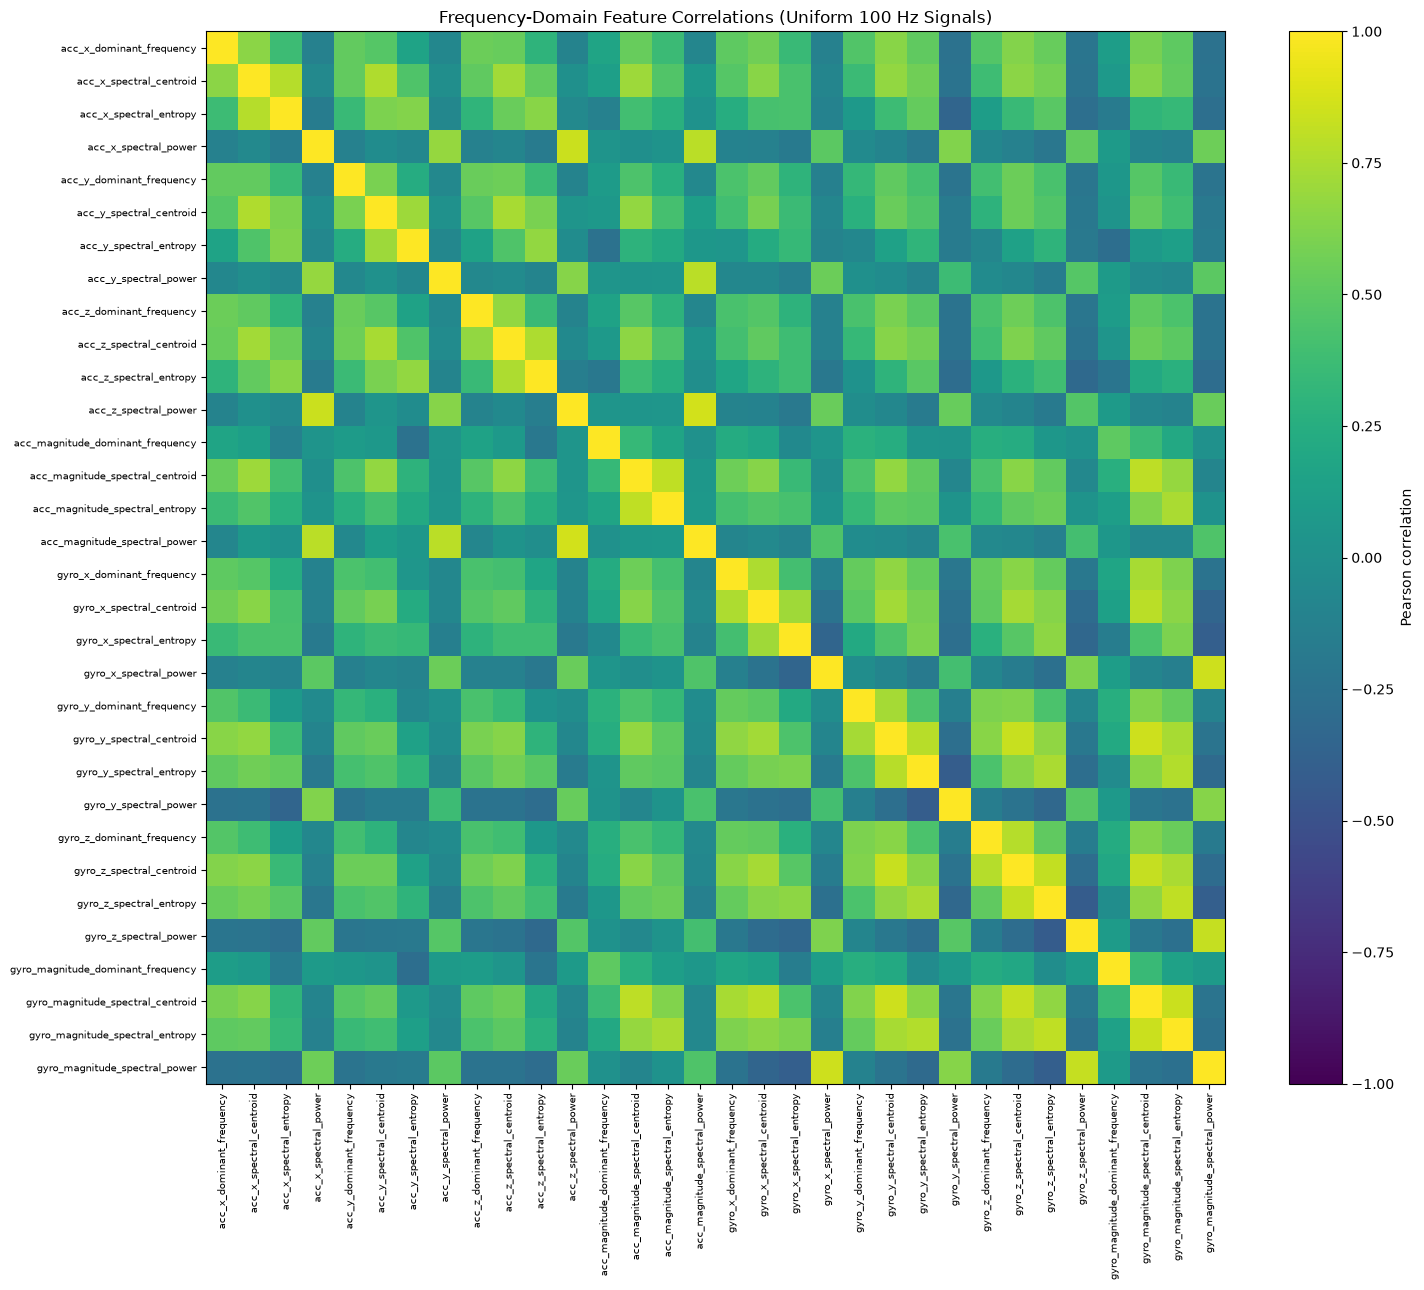

In [14]:
figure, axis = plt.subplots(figsize=(15, 13))

image = axis.imshow(
    correlation_matrix.to_numpy(),
    aspect="auto",
    vmin=-1,
    vmax=1,
)

axis.set_xticks(range(len(correlation_matrix.columns)))
axis.set_xticklabels(
    correlation_matrix.columns,
    rotation=90,
    fontsize=7,
)

axis.set_yticks(range(len(correlation_matrix.index)))
axis.set_yticklabels(
    correlation_matrix.index,
    fontsize=7,
)

axis.set_title(
    "Frequency-Domain Feature Correlations "
    "(Uniform 100 Hz Signals)"
)

figure.colorbar(
    image,
    ax=axis,
    label="Pearson correlation",
)

figure.tight_layout()
plt.show()


## 10. Strongly Correlated Wearable Features

In [15]:
strong_correlations = summarize_strong_correlations(
    correlation_matrix,
    threshold=STRONG_CORRELATION_THRESHOLD,
)

print("Strongly correlated pairs:", len(strong_correlations))
strong_correlations.head(30)


Strongly correlated pairs: 12


,feature_1,feature_2,correlation,absolute_correlation,direction,relationship_group
0,acc_z_spectral_power,acc_magnitude_spectral_power,0.861406,0.861406,Positive,Accelerometer
1,gyro_x_spectral_power,gyro_magnitude_spectral_power,0.847568,0.847568,Positive,Gyroscope
2,gyro_y_spectral_centroid,gyro_magnitude_spectral_centroid,0.845527,0.845527,Positive,Gyroscope
3,acc_x_spectral_power,acc_z_spectral_power,0.842132,0.842132,Positive,Accelerometer
4,gyro_magnitude_spectral_centroid,gyro_magnitude_spectral_entropy,0.839505,0.839505,Positive,Gyroscope
5,gyro_y_spectral_centroid,gyro_z_spectral_centroid,0.828559,0.828559,Positive,Gyroscope
6,gyro_z_spectral_centroid,gyro_magnitude_spectral_centroid,0.821964,0.821964,Positive,Gyroscope
7,gyro_z_spectral_power,gyro_magnitude_spectral_power,0.821192,0.821192,Positive,Gyroscope
8,gyro_z_spectral_centroid,gyro_z_spectral_entropy,0.812565,0.812565,Positive,Gyroscope
9,acc_magnitude_spectral_centroid,acc_magnitude_spectral_entropy,0.810669,0.810669,Positive,Accelerometer


In [16]:
if strong_correlations.empty:
    strong_correlation_group_summary = pd.DataFrame(
        columns=[
            "relationship_group",
            "direction",
            "feature_pairs",
        ]
    )
else:
    strong_correlation_group_summary = (
        strong_correlations
        .groupby(
            ["relationship_group", "direction"],
            as_index=False,
        )
        .size()
        .rename(columns={"size": "feature_pairs"})
    )

strong_correlation_group_summary


,relationship_group,direction,feature_pairs
0,Accelerometer,Positive,3
1,Cross-sensor,Positive,1
2,Gyroscope,Positive,8


## 11. Save Correlation and Resampling Outputs

In [17]:
correlation_summary = build_correlation_summary(
    feature_table=frequency_features,
    strong_correlations=strong_correlations,
    threshold=STRONG_CORRELATION_THRESHOLD,
)

additional_summary_rows = pd.DataFrame(
    {
        "metric": [
            "Target sampling frequency (Hz)",
            "Recordings with preserved post-trim length",
            "Observed post-trim lengths",
        ],
        "value": [
            TARGET_SAMPLING_FREQUENCY,
            int(lengths_preserved.sum()),
            ", ".join(
                str(value)
                for value in sorted(observed_lengths)
            ),
        ],
    }
)

correlation_summary = pd.concat(
    [correlation_summary, additional_summary_rows],
    ignore_index=True,
)

CORRELATION_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

correlation_matrix.to_csv(CORRELATION_MATRIX_OUTPUT)

strong_correlations.to_csv(
    STRONG_CORRELATIONS_OUTPUT,
    index=False,
)

correlation_summary.to_csv(
    CORRELATION_SUMMARY_OUTPUT,
    index=False,
)

post_resampling_length_summary.to_csv(
    RESAMPLING_LENGTH_OUTPUT,
    index=False,
)

output_paths = [
    CORRELATION_MATRIX_OUTPUT,
    STRONG_CORRELATIONS_OUTPUT,
    CORRELATION_SUMMARY_OUTPUT,
    RESAMPLING_LENGTH_OUTPUT,
]

for output_path in output_paths:
    if not output_path.exists() or output_path.stat().st_size == 0:
        raise IOError(
            f"Output was not saved correctly: {output_path}"
        )
    print("Saved:", output_path)

correlation_summary


Saved: c:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\tables\correlation_analysis\frequency_feature_correlation_matrix.csv
Saved: c:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\tables\correlation_analysis\strongly_correlated_features.csv
Saved: c:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\tables\correlation_analysis\correlation_analysis_summary.csv
Saved: c:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\tables\correlation_analysis\post_resampling_length_summary.csv


,metric,value
0,Recordings analysed,10318.0
1,Participants analysed,469.0
2,Motor tasks,11.0
3,Wrists,2.0
4,Accelerometer frequency features,16.0
5,Gyroscope frequency features,16.0
6,Strong-correlation threshold,0.8
7,Strongly correlated feature pairs,12.0
8,Accelerometer-only strong pairs,3.0
9,Gyroscope-only strong pairs,8.0


## 12. Final Summary

Upon successful execution, this notebook confirms that:

- all 469 participant files were processed;
- 10,318 recordings were analyzed;
- every recording was interpolated onto a uniform 100 Hz grid before FFT-based feature extraction;
- the original timestamp-based sampling frequency was retained only for QA;
- the post-trim lengths of 976 and 2,000 samples were preserved;
- 32 frequency-domain features were generated;
- accelerometer and gyroscope feature groups were created;
- correlation outputs were generated and saved; and
- strongly correlated wearable feature pairs were identified using `|r| ≥ 0.80`.
